# Download station XML

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from obspy.clients.fdsn.client import Client
from obspy import UTCDateTime
from obspy.core.event import Catalog
from obspy.core.event import Event
from obspy.core.event import Origin
from obspy.core.event import Magnitude
from obspy.core.event.base import Comment
from obspy.core.event import ResourceIdentifier
from obspy.core.inventory import Inventory
from obspy import read_events
from obspy import read_inventory
from pyrocko import util, model, io, trace, moment_tensor, gmtpy
from obspy.core.stream import Stream
from obspy import read

In [ ]:
workdir='../'
meta_data_dir= os.path.join(workdir,'META_DATA')
stations_name='stations_garfagnana_INGV_RESIF_2'           ### CHANGE ###


clients_networks = {
    Client("INGV"): ["IV", "GU"],
    Client("RESIF"): ["FR"],
}
starttime = UTCDateTime("2025-01-01")
endtime = UTCDateTime("2026-03-25")
lat=44.1507
lon=10.0467
minradius=0.0
maxradius=2.0 # ~220km

inventory=Inventory()
for client, networks in clients_networks.items():
    for net in networks:
        inventory += client.get_stations(network=net,starttime=starttime,endtime=endtime,
                                channel='HH*',level="response",
                                latitude=lat,longitude=lon,
                                minradius=minradius,maxradius=maxradius)

In [ ]:
# print the inventory to check the retrieved stations
print(inventory)

In [ ]:
# plot inventory
inventory.plot(projection="local",resolution='h');

# SAVE inventory

In [ ]:
stations_xml_path=os.path.join(meta_data_dir,stations_name + '.xml')

inventory.write(stations_xml_path,format="STATIONXML")

### EXTRA: remove unwanted stations

In [ ]:
remove_stations= False
# remove stations tha are not recording 
#list_stations= ['SEI','MGRO','CANO','ASQU','BDI','BOB','BRIS','CELB','CSNT','ERBM','SEI','MCECU','MON']

# remove stations with low SNR or with similar azimuhtal coverage
list_stations=['RNCA','ROTM','FNVD','BOSL','FIR','NDIM','LMD','VMAN','ORZI','OPPE','MILN','MALA0','CMAG']

if remove_stations: 
    inv_new=inventory.copy()
    for station in list_stations:
        inv_new=inv_new.remove(station=station)

    # save new inventory
    stations_xml_name='stations_garfagnana_INGV_RESIF_2'           ### CHANGE ###
    stations_xml_path=os.path.join(meta_data_dir,stations_xml_name + '.xml')

    inv_new.write(stations_xml_path,format="STATIONXML")

    # print new inventory
    print(inv_new)
    # plot new inventory
    inv_new.plot(projection="local",resolution='i');

# CREATE .pf station file 

In [ ]:
#stations_xml_path='../META_DATA/stations_garfagnana_UP.xml' ### CHANGE ###
#stations_name='stations_garfagnana_UP'   ### CHANGE ###
inventory=read_inventory(stations_xml_path)

inventory_pf=[]
for network in inventory:
    for station in network:
        
        lat= str(station.latitude)
        lon= str(station.longitude)
        elev=str(station.elevation)
        elev_corr= '0.00'

        net_sta= str(network.code) +'.'+ str(station.code)  +'.'

        st_line= "{:13s} {:15s} {:15s} {:11s} {:s}".format(net_sta, lat, lon, elev, elev_corr)
        inventory_pf.append(st_line)
        ch_name=[]
        counter_multiple_channels=0
        for ch in station.channels:
            # check for multiple channels and save only one per station
            if ch.code not in ch_name:
                ch_name.append(ch.code)

                azi= str( int( round( ch.azimuth ) ) )
                dip= str( int( round( ch.dip ) ) )
                ch_line= "  {:14s} {:15s} {:15s} 1".format(ch.code, azi, dip )
                inventory_pf.append(ch_line)
            else:
                if counter_multiple_channels==0:
                    print(f"Warning: Station {net_sta} has multiple channels with same name, only one will be saved in the .pf file")
                counter_multiple_channels+=1
                print(f"{ch.code}\tAzimuth: {ch.azimuth}\tDip: {ch.dip}")

station_name=os.path.join(meta_data_dir, stations_name + '.pf')

with open(station_name, 'w') as out:
    for l in inventory_pf:
        out.write(l + '\n')

# -------
# -------
# TESTS
# -------
# -------

## Local Velocity Model

In [ ]:
import numpy as np

vp = np.array((3.8, 4., 4.4, 5.4, 6.03, 6.17, 6.44, 6.51, 8.10))

vs = vp/1.7 # ratio from the paper 

f=3280.84   #from km to ft
rho = 0.23 * (vp*f)**0.25 # Gardener law 1974

print('vp:', vp)
print('\nvs:', vs)
print('\nrho:', rho)

#print('rho:')
#for i in range(len(rho)):
#    print(rho[i])

# -------
## Eliminate location '00' from traces
### (Eliminate location '00' from xlm by hand)

In [5]:
from pyrocko import io
workdir='../'
data_dir= os.path.join(workdir,'DATA')
data_dir_garf=os.path.join(data_dir,'garfagnana_2026_03_25_07_13_43')

tr_name='garfagnana_FR_TURF_2026_03_25_07_13_43'
tr_path=os.path.join(data_dir_garf, tr_name + '.mseed') #CHANGE
traces = io.load(tr_path)

for tr in traces:
    tr.location = ''
    print(tr.nslc_id)

new_path = os.path.join(data_dir_garf, tr_name + '.mseed') #CHANGE
io.save(traces, new_path )

('FR', 'TURF', '00', 'HHE')
('FR', 'TURF', '00', 'HHN')
('FR', 'TURF', '00', 'HHZ')


['../DATA/garfagnana_2026_03_25_07_13_43/garfagnana_FR_TURF_2026_03_25_07_13_43.mseed']

# ------
## Merge two .xml files

In [2]:
workdir='../'
meta_data_dir= os.path.join(workdir,'META_DATA')

path_inv_INGV=os.path.join(meta_data_dir,'stations_garfagnana_INGV_RESIF.xml') # CHANGE
path_inv_UNIPI=os.path.join(meta_data_dir,'stations_garfagnana_UP.xml') # CHANGE

inv_INGV=read_inventory(path_inv_INGV)
inv_UNIPI=read_inventory(path_inv_UNIPI)

inv_merge=Inventory()
inv_merge += inv_INGV
inv_merge += inv_UNIPI

path_inv_merge=os.path.join(meta_data_dir,'stations_garfagnana_INGV_RESIF_UP.xml') # CHANGE
inv_merge.write(path_inv_merge,format="STATIONXML")
print(inv_merge)

Inventory created at 2026-03-30T15:42:11.799026Z
	Created by: ObsPy 1.4.0
		    https://www.obspy.org
	Sending institution: ObsPy 1.4.0,RESIF-SI,eXistDB (INGV-ONT,RESIF-DC)
	Contains:
		Networks (4):
			FR, GU, IV, UP
		Stations (57):
			FR.ESCA (L'Escarène)
			FR.MORSI (Morsiglia)
			FR.SAOF (Saorge)
			FR.TURF (col de Turini)
			GU.CARD (Cardoso-Stazzema(LU) - Italy)
			GU.EQUI (Equi Terme (MS) - Italy)
			GU.GBOS (Grotte di Bossea (CN) - Italy)
			GU.GORR (Gorreto (GE) - Italy)
			GU.GRAM (Graiana (PR) - Italy)
			GU.GSCL (Gusciola (MO) - Italy)
			GU.IMI (IMPERIA)
			GU.MAIM (Mastiano (LU) - Italy)
			GU.PCP (Piancastagna, Ponzone (AL) - Italy)
			GU.POPM (Popiglio,Piteglio(PT) - Italy)
			GU.RORO (Castelbianco (SV) - Italy)
			IV.ARCI (Arcidosso)
			IV.ATMI (AVT - Monte Miggiano)
			IV.BOZZ (Bozzolo (MN))
			IV.CAFI (Castiglion Fiorentino)
			IV.CAIS (CAIS)
			IV.CASP (Castiglione della Pescaia)
			IV.CAVE (Cavezzo)
			IV.CRE (CAPRESE MICHELANGELO)
			IV.CRMI (Carmignano)
			IV.CT

## Merge traces

In [ ]:
workdir='../'
data_dir= os.path.join(workdir,'DATA')
st_dir=os.path.join(data_dir,'UP08')    #CHANGE
net_name='UP'
st_name='08' #CHANGE

cat_dir=os.path.join(workdir,'CAT')

cat_path=os.path.join(cat_dir,'catalogue_garfagnana_ml_4.pf')
cat=model.load_events(cat_path)
print(f'event:{cat[0].name}')

origin_time = UTCDateTime(util.time_to_str(cat[0].time))
shift=300 # s
time1=origin_time-shift
time2=origin_time+shift

stream=Stream()
for file_name in os.listdir(st_dir):
    if not file_name.startswith('.'):
        #print(file)
        tr_path=os.path.join(st_dir,file_name)
        tr=read(os.path.join(tr_path))

        tr.trim(time1,time2)
        stream+=tr

print(stream)
stream_name='garfagnana_' + net_name + '_' + net_name + st_name + '_2026_03_25_07_13_43.mseed'
stream_path=os.path.join(st_dir,stream_name)
stream.write(stream_path,format='MSEED')


### PLOT inventory

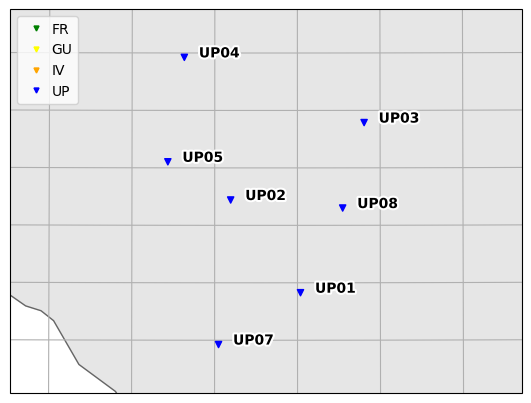

In [ ]:
workdir='../'
meta_data_dir= os.path.join(workdir,'META_DATA')

path_inv=os.path.join(meta_data_dir,'stations_garfagnana_UP.xml')

inv=read_inventory(path_inv)
#print(inv)
inv.plot(projection="local",resolution='h',size=20,label=True,
            color_per_network={"IV": "orange", "UP": "blue", "FR": "green", "GU": "yellow"},
            outfile='../PLOTS/INV_MAP/stations_garfagnana_UP.png');